In [1]:
import os
from dotenv import load_dotenv
load_dotenv()


True

In [2]:
from google import genai
from google.genai import types
from typing_extensions import TypedDict, Dict, Any
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

--- WORKFLOW ---


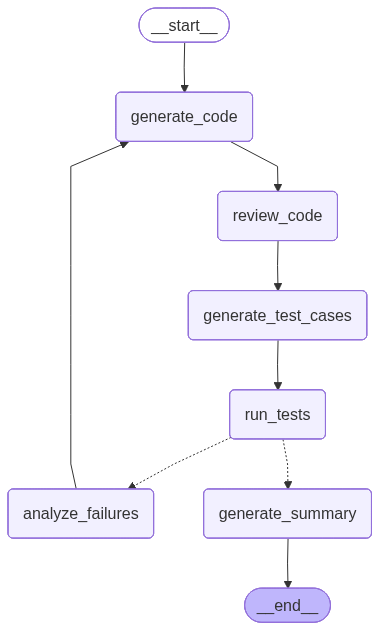

--- GENERATING CODE ---
--- ITERATION : 0 ---
--- REVIEWING CODE ---
--- GENERATING TEST CASES ---
Saved test cases to test_cases.py
--- RUNNING TESTS (Locally via subprocess) ---
--- GENERATING SUMMARY ---


=== FINAL SUMMARY ===
Workflow Status: SUCCESS
Iterations: 1

Final Code:
def find_two_sum_indices(nums, target):
    """
    Finds two indices such that the numbers at those indices add up to the target.
    Returns the indices sorted in ascending order.
    """
    num_map = {}
    for i, num in enumerate(nums):
        complement = target - num
        if complement in num_map:
            return sorted([num_map[complement], i])
        num_map[num] = i
    return []

Test Logs:
........                                                                 [100%]
8 passed in 0.02s


Review Feedback:
The code is efficient with O(n) time and space complexity. Bug/Logic: The 'sorted()' call is unnecessary because 'num_map[complement]' is always less than 'i', so returning '[num_map[comp

In [7]:
import operator
import traceback
from typing import TypedDict, Annotated, Dict, Any

from langgraph.graph import StateGraph, END
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel, Field

from e2b_code_interpreter import Sandbox
import subprocess

# ---------------------------------------------------------
# 1. Define Pydantic Schemas for Output Parsers
# ---------------------------------------------------------
class CodeGeneration(BaseModel):
    code: str = Field(description="The complete, executable Python code block.")

class ReviewGeneration(BaseModel):
    review_feedback: str = Field(description="Concise feedback on bugs, efficiency, and edge cases.")

class TestGeneration(BaseModel):
    test_cases: str = Field(description="The complete pytest code block testing the provided code.")

class AnalysisGeneration(BaseModel):
    analysis: str = Field(description="Analysis of why the code failed and explanation of how to fix it.")

# ---------------------------------------------------------
# 2. Define the Graph State
# ---------------------------------------------------------
class GraphState(TypedDict):
    requirement: str
    code: str
    review_feedback: str
    test_cases: str
    test_results: Dict[str, Any]
    analysis: str
    summary: str
    iterations: int

# Initialize the LangChain LLM wrapper for Gemini
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite-preview", temperature=0)

# ---------------------------------------------------------
# 3. Define the Nodes with LCEL Chains
# ---------------------------------------------------------
def generate_code(state: GraphState):
    print("--- GENERATING CODE ---")
    requirement = state.get("requirement")
    analysis = state.get("analysis", "")
    iterations = state.get("iterations", 0)
    print(f"--- ITERATION : {iterations} ---")
    parser = PydanticOutputParser(pydantic_object=CodeGeneration)
    
    # Define the template with partial variables for the parser instructions
    template = (
        "Write Python code to fulfill this requirement: {requirement}\n"
        "{analysis_block}\n"
        "Please provide the corrected, complete code block.\n"
        "\n{format_instructions}"
    )
    
    prompt = PromptTemplate(
        template=template,
        input_variables=["requirement", "analysis_block"],
        partial_variables={"format_instructions": parser.get_format_instructions()}
    )
    
    # Create the LCEL Chain
    chain = prompt | llm | parser
    
    # Format the dynamic analysis block
    analysis_block = f"\nThe previous tests failed. Analysis and requested fixes:\n{analysis}" if analysis else ""
    
    # Invoke the chain directly
    parsed_output = chain.invoke({
        "requirement": requirement, 
        "analysis_block": analysis_block
    })
    
    return {"code": parsed_output.code, "iterations": iterations + 1}

def review_code(state: GraphState):
    print("--- REVIEWING CODE ---")
    parser = PydanticOutputParser(pydantic_object=ReviewGeneration)
    
    prompt = PromptTemplate(
        template="Review the following Python code for bugs, efficiency, and edge cases. Provide concise feedback.\nCode:\n{code}\n\n{format_instructions}",
        input_variables=["code"],
        partial_variables={"format_instructions": parser.get_format_instructions()}
    )
    
    # LCEL Chain
    chain = prompt | llm | parser
    parsed_output = chain.invoke({"code": state["code"]})
    
    return {"review_feedback": parsed_output.review_feedback}

def generate_test_cases(state: GraphState):
    print("--- GENERATING TEST CASES ---")
    parser = PydanticOutputParser(pydantic_object=TestGeneration)
    
    prompt = PromptTemplate(
        template="Write Python `pytest` style test cases for the following code. Ensure you test edge cases.\nCode:\n{code}\n\n{format_instructions}",
        input_variables=["code"],
        partial_variables={"format_instructions": parser.get_format_instructions()}
    )
    
    # LCEL Chain
    chain = prompt | llm | parser
    parsed_output = chain.invoke({"code": state["code"]})
    tests = parsed_output.test_cases

    # Save the generated tests to a local file
    with open("test_cases.py", "w", encoding="utf-8") as file:
        file.write(tests)
    
    print("Saved test cases to test_cases.py")
    return {"test_cases": tests}



def run_tests(state: GraphState):
    print("--- RUNNING TESTS (Locally via subprocess) ---")
    code = state["code"]
    tests = state["test_cases"]
    
    execution_script = f"{code}\n\n{tests}"
    
    try:
        # Write the combined code and tests to a local file
        with open("test_cases.py", "w", encoding="utf-8") as f:
            f.write(execution_script)
            
        # Run pytest locally
        result = subprocess.run(
            ["python", "-m", "pytest", "test_cases.py", "-q"], 
            capture_output=True, 
            text=True
        )
        
        if result.returncode == 0:
            return {"test_results": {"passed": True, "logs": result.stdout}}
        else:
            error_logs = f"Stdout:\n{result.stdout}\n\nStderr:\n{result.stderr}"
            return {"test_results": {"passed": False, "logs": error_logs.strip()}}
            
    except Exception as e:
        error_log = traceback.format_exc()
        return {"test_results": {"passed": False, "logs": f"Local Execution Error:\n{error_log}"}}

def analyze_failures(state: GraphState):
    print("--- ANALYZING FAILURES ---")
    parser = PydanticOutputParser(pydantic_object=AnalysisGeneration)
    
    prompt = PromptTemplate(
        template="The following code failed its tests.\n\nCode:\n{code}\n\nError Logs:\n{logs}\n\nAnalyze why it failed and explain exactly how to fix the code.\n\n{format_instructions}",
        input_variables=["code", "logs"],
        partial_variables={"format_instructions": parser.get_format_instructions()}
    )
    
    # LCEL Chain
    chain = prompt | llm | parser
    parsed_output = chain.invoke({
        "code": state["code"], 
        "logs": state["test_results"]["logs"]
    })
    
    return {"analysis": parsed_output.analysis}

def generate_summary(state: GraphState):
    print("--- GENERATING SUMMARY ---")
    status = "SUCCESS" if state["test_results"]["passed"] else "FAILED (Max retries reached)"
    # Add the logs to the summary so you can see exactly what failed!
    logs = state.get("test_results", {}).get("logs", "No logs available.")
    
    summary = (
        f"Workflow Status: {status}\n"
        f"Iterations: {state['iterations']}\n\n"
        f"Final Code:\n{state['code']}\n\n"
        f"Test Logs:\n{logs}\n\n" # <--- ADD THIS
        f"Review Feedback:\n{state['review_feedback']}"
    )
    
    return {"summary": summary}

# ---------------------------------------------------------
# 4. Define Conditional Routing
# ---------------------------------------------------------
def route_after_tests(state: GraphState):
    if state["test_results"]["passed"]:
        return "generate_summary"
    elif state["iterations"] >= 3:
        print("--- MAX ITERATIONS REACHED ---")
        return "generate_summary"
    else:
        return "analyze_failures"

# ---------------------------------------------------------
# 5. Build the Graph
# ---------------------------------------------------------
workflow = StateGraph(GraphState)

workflow.add_node("generate_code", generate_code)
workflow.add_node("review_code", review_code)
workflow.add_node("generate_test_cases", generate_test_cases)
workflow.add_node("run_tests", run_tests)
workflow.add_node("analyze_failures", analyze_failures)
workflow.add_node("generate_summary", generate_summary)

workflow.set_entry_point("generate_code")
workflow.add_edge("generate_code", "review_code")
workflow.add_edge("review_code", "generate_test_cases")
workflow.add_edge("generate_test_cases", "run_tests")

workflow.add_conditional_edges(
    "run_tests",
    route_after_tests,
    {
        "generate_summary": "generate_summary",
        "analyze_failures": "analyze_failures"
    }
)

workflow.add_edge("analyze_failures", "generate_code")
workflow.add_edge("generate_summary", END)

app = workflow.compile()

print("--- WORKFLOW ---")
display(Image(app.get_graph().draw_mermaid_png()))
# ---------------------------------------------------------
# 6. Execute the Workflow
# ---------------------------------------------------------
if __name__ == "__main__":
    initial_state = {
    "requirement": "Write a Python function. A list of integers and a target value are given; find two numbers that add up to the target. The function MUST return a list containing the two INDICES of the numbers, sorted in ascending order.",
    "iterations": 0
}
    
    final_state = app.invoke(initial_state)
    print("\n\n=== FINAL SUMMARY ===")
    print(final_state["summary"])